In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import seaborn as sns
import os
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [6]:
dof1_force = np.load("dummy_ninapro_data\dof1_forces.npy")
dof1_labels = np.load("dummy_ninapro_data\dof1_labels.npy")
dof1_signals = np.load("dummy_ninapro_data\dof1_signals.npy")
mvc_signals = np.load("dummy_ninapro_data\mvc_signals.npy")
mvc_labels = np.load("dummy_ninapro_data\mvc_labels.npy")
mvc_values = np.load("dummy_ninapro_data\mvc_values.npy")
ndof_signals = np.load("dummy_ninapro_data\\ndof_signals.npy")
ndof_labels = np.load("dummy_ninapro_data\\ndof_labels.npy")
ndof_combo_map = np.load("dummy_ninapro_data\\ndof_combo_map.npy", allow_pickle=True)
pr_signals = np.load("dummy_ninapro_data\\pr_signals.npy")
pr_labels = np.load("dummy_ninapro_data\\pr_labels.npy")


<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\m'
<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\m'
<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
C:\Users\vin1\AppData\Local\Temp\ipykernel_3888\543196072.py:1: SyntaxWarning: invalid escape sequence '\d'
  dof1_force = np.load("dummy_ninapro_data\dof1_forces.npy")
C:\Users\vin1\AppData\Local\Temp\ipykernel_3888\543196072.py:2: SyntaxWarning: invalid escape sequence '\d'
  dof1_labels = np.load("dummy_ninapro_data\dof1_labels.npy")
C:\Users\vin1\AppData\Local\Temp\ipykernel_3888\543196072.py:

In [7]:
sample = pr_signals[1]

print("Min:", sample.min())
print("Max:", sample.max())
print("Std:", sample.std())

Min: -0.7669167675123808
Max: 0.7370137927525632
Std: 0.17434089585498236


In [8]:
sample = pr_signals[1]  # shape (200, 14)

df = pd.DataFrame(sample)

print(df.head(16))


          0         1         2         3         4         5         6   \
0  -0.025192 -0.030932  0.039015  0.019603 -0.077904 -0.026860  0.094472   
1   0.024953 -0.003917 -0.015396  0.039896 -0.018698 -0.066314  0.086277   
2  -0.016976 -0.048299 -0.025634 -0.080220  0.058045 -0.003721  0.150939   
3  -0.009682 -0.027715  0.029120 -0.074806 -0.042930 -0.014306  0.126418   
4  -0.086574 -0.032138  0.050115 -0.011660 -0.022787 -0.011266 -0.042440   
5   0.003431 -0.001008 -0.005957  0.008984 -0.043958  0.105965  0.080408   
6  -0.025778 -0.003757 -0.137560  0.014707 -0.003491 -0.095315  0.057544   
7  -0.002600 -0.049465  0.066439  0.025247  0.032106  0.028016 -0.023727   
8   0.039569  0.053315 -0.007950  0.078515 -0.033041  0.022136 -0.010006   
9  -0.079213 -0.128283 -0.082388 -0.016794 -0.025069  0.101459  0.073820   
10  0.033702  0.038784 -0.092028  0.113742  0.021553 -0.024672 -0.023554   
11 -0.107677  0.009985  0.012100  0.011810 -0.074179 -0.057865 -0.018229   
12  0.020176

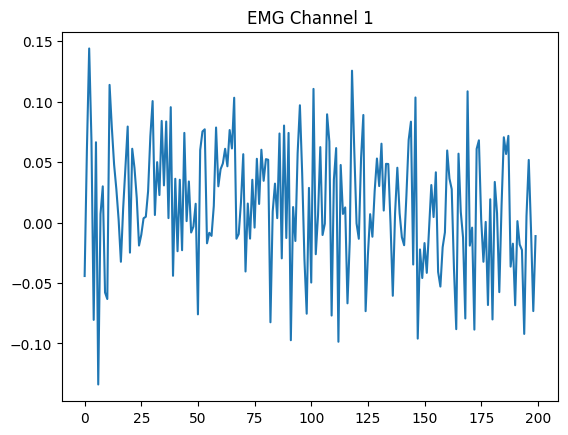

In [9]:
plt.plot(pr_signals[2][:, 3:4])  # EMG channel 1
plt.title("EMG Channel 1")
plt.show()

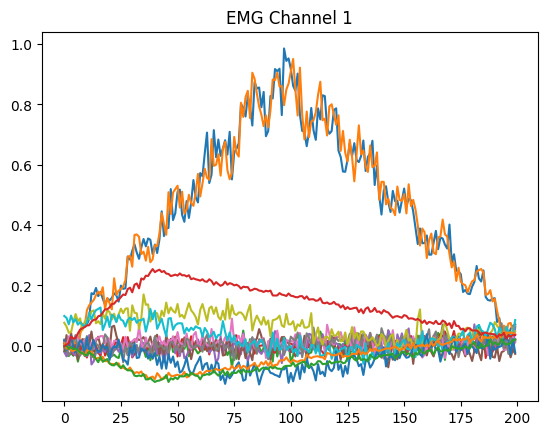

In [10]:
plt.plot(dof1_signals[3])  # EMG channel 1
plt.title("EMG Channel 1")
plt.show()

In [11]:
print("Signals shape:", mvc_signals.shape)
print("Labels shape:", mvc_labels.shape)
print("Unique gesture classes:", np.unique(mvc_labels))
print("Data type:", mvc_signals.dtype)

Signals shape: (250, 200, 14)
Labels shape: (250,)
Unique gesture classes: [0 1 2 3 4]
Data type: float64


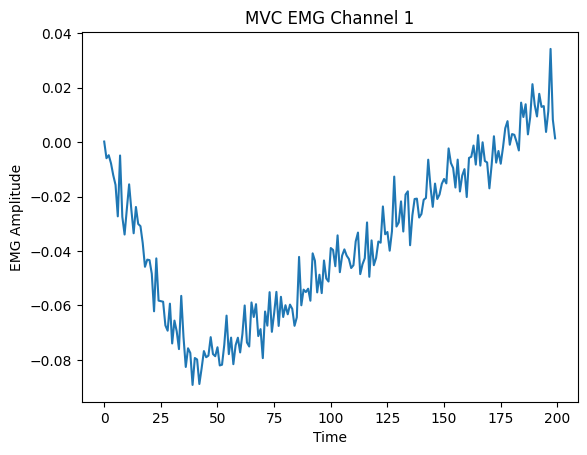

In [63]:
plt.plot(mvc_signals[0][:, 13])  # EMG channel 1
plt.title("MVC EMG Channel 1")
plt.xlabel("Time")
plt.ylabel("EMG Amplitude")
plt.show()

In [13]:
def extract_features(window):
    # window shape: (200, 14)
    
    # RMS — square every value, take mean across time, then square root
    # axis=0 means we compute along the time axis, giving one value per channel
    rms = np.sqrt(np.mean(window**2, axis=0))        # shape: (14,)
    
    # MAV — absolute value of every sample, then mean across time
    mav = np.mean(np.abs(window), axis=0)             # shape: (14,)
    
    # ZC — check where consecutive samples have opposite signs
    # multiplying adjacent samples: if signs differ, product is negative
    # so we count where the product is less than zero
    zc = np.sum(window[:-1] * window[1:] < 0, axis=0) # shape: (14,)
    
    # WL — absolute difference between consecutive samples, summed across time
    wl = np.sum(np.abs(np.diff(window, axis=0)), axis=0) # shape: (14,)

    return np.concatenate([rms, mav, zc, wl])

In [14]:
X = np.array([extract_features(mvc_signals[i]) for i in range(len(mvc_signals))])
y = mvc_labels

print("Feature matrix shape:", X.shape)  # should be (250, 56)
print("Labels shape:", y.shape)           # should be (250,)

Feature matrix shape: (250, 56)
Labels shape: (250,)


In [68]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [69]:
x_train_df = pd.DataFrame(X_train, columns=[f"rms_ch{i+1}" for i in range(14)] +
                                  [f"mav_ch{i+1}" for i in range(14)] +
                                  [f"zc_ch{i+1}" for i in range(14)] +
                                  [f"wl_ch{i+1}" for i in range(14)])
x_train_df['label'] = y_train
x_train_df 

,rms_ch1,rms_ch2,rms_ch3,rms_ch4,rms_ch5,rms_ch6,rms_ch7,rms_ch8,rms_ch9,rms_ch10,...,wl_ch6,wl_ch7,wl_ch8,wl_ch9,wl_ch10,wl_ch11,wl_ch12,wl_ch13,wl_ch14,label
0,0.087606,0.430314,0.500777,0.085204,0.031662,0.047299,0.036032,0.030734,0.519255,0.150762,...,7.882897,6.954139,6.597974,4.267847,4.606663,4.939370,1.401532,1.561984,1.395364,1
1,0.457926,0.405441,0.062549,0.037406,0.034371,0.037960,0.034236,0.033049,0.070024,0.061592,...,6.700026,6.734254,6.886325,4.125810,4.841564,4.474672,1.351071,1.538958,1.416381,0
2,0.032856,0.101675,0.522417,0.426506,0.072563,0.036281,0.037260,0.036354,0.796333,0.092542,...,6.479871,6.576261,6.987279,4.933116,4.561221,3.844390,1.347130,1.426511,1.345142,2
3,0.057022,0.440061,0.480639,0.070586,0.030278,0.028910,0.037282,0.035240,0.511586,0.185523,...,6.246090,6.936416,6.867701,4.758248,4.383603,5.050126,1.384678,1.324699,1.370792,1
4,0.085153,0.550621,0.398997,0.076878,0.031940,0.032089,0.031032,0.037073,0.464069,0.193929,...,6.830584,6.006099,6.261924,4.789240,4.518211,4.652262,1.371236,1.375131,1.275943,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,0.041307,0.092455,0.443114,0.393681,0.052418,0.036233,0.037406,0.030233,0.785555,0.063875,...,6.929337,6.530452,6.846068,4.860966,4.559062,4.360056,1.418040,1.450270,1.407618,2
196,0.463076,0.455328,0.079060,0.045738,0.033442,0.034529,0.041331,0.033216,0.098490,0.047034,...,6.907521,6.347409,6.927842,4.519624,5.044901,4.727425,1.482422,1.484978,1.345678,0
197,0.034199,0.032963,0.075581,0.473228,0.397585,0.073994,0.034120,0.040756,0.047448,0.700342,...,21.033294,6.335865,7.474510,4.528983,4.374809,3.942438,1.437940,1.451233,1.480295,3
198,0.035787,0.030775,0.037846,0.058419,0.409160,0.465659,0.061407,0.034449,0.268923,0.440755,...,102.939714,11.798040,7.453810,4.623055,4.431413,4.739098,1.448514,1.290522,1.454928,4


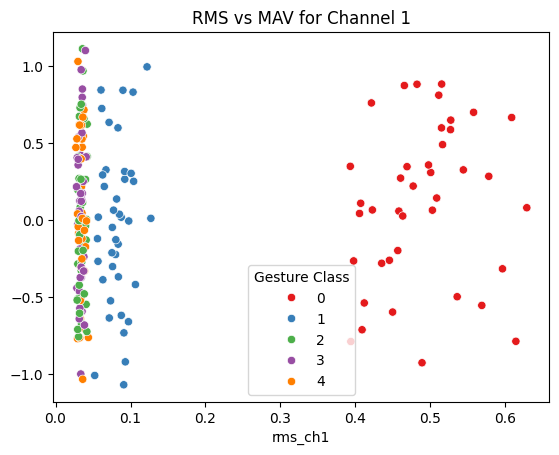

In [80]:
scatter = sns.scatterplot(data=x_train_df, x='rms_ch1', y=mvc_signals[2][:, 1], hue='label', palette='Set1')
scatter.set_title("RMS vs MAV for Channel 1")
plt.legend(title='Gesture Class')

In [86]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# Scale the features first — SVM is sensitive to feature scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train SVM with RBF kernel
svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm.fit(X_train_scaled, y_train)
svm.get_params()


{'C': 1.0,
 'break_ties': False,
 'cache_size': 200,
 'class_weight': None,
 'coef0': 0.0,
 'decision_function_shape': 'ovr',
 'degree': 3,
 'gamma': 'scale',
 'kernel': 'rbf',
 'max_iter': -1,
 'probability': False,
 'random_state': 42,
 'shrinking': True,
 'tol': 0.001,
 'verbose': False}

In [84]:
from sklearn.model_selection import GridSearchCV
GSC= GridSearchCV(estimator=SVC(random_state=42),
                 param_grid={'C': [0.1, 1, 10], 'gamma': ['scale', 'auto']},
                 cv=5, n_jobs=-1)

In [ ]:
GSC.fit(X_train_scaled, y_train)
best_params = GSC.best_params_
print(best_params)